# 10K 3-Way Comparison: AE vs VAE v1 vs VAE v2 (Beta)

This notebook performs a definitive side-by-side evaluation of all three architectures trained on the exact same 10K deterministic dataset. We evaluate the standard Autoencoder, the original blurry VAE v1 (KL Overload), and the corrected VAE v2 ($\\beta$-VAE).


In [11]:
import os
import random
import hashlib
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. Load the Test Split
We reconstruct the identical 1000-image test set using the exact same deterministic Seed=42.


In [12]:
!pip install -q datasets
from datasets import load_dataset
dataset = load_dataset("evilsocket/alucard-sprites")
train_data = dataset["train"]

def image_hash(image):
    pixels = np.asarray(image.convert("RGBA"), dtype=np.uint8)
    return hashlib.sha256(pixels.tobytes()).hexdigest()

all_hashes = []
seen_hashes = set()
for i, item in enumerate(train_data):
    h = image_hash(item["image"])
    if h not in seen_hashes:
        seen_hashes.add(h)
        all_hashes.append(i)

unique_dataset = train_data.select(all_hashes)
unique_dataset = unique_dataset.shuffle(seed=42)

TRAIN_SIZE = 9_000
VAL_SIZE = 1_000
TEST_SIZE = 1_000
TOTAL_SIZE = TRAIN_SIZE + VAL_SIZE + TEST_SIZE

clean_dataset = unique_dataset.select(range(TOTAL_SIZE))
test_dataset = clean_dataset.select(range(TRAIN_SIZE + VAL_SIZE, TOTAL_SIZE))

test_originals = []
for item in test_dataset:
    img = np.asarray(item["image"].convert("RGBA"), dtype=np.float32) / 255.0
    test_originals.append(img)
test_originals = np.array(test_originals)
print("Test originals loaded:", test_originals.shape)



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\manis\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Test originals loaded: (1000, 128, 128, 4)


## 2. Load All Three Architectures


In [13]:
# --- STANDARD AUTOENCODER ---
ae_encoder = keras.Sequential([
    layers.Input(shape=(128, 128, 4)),
    layers.Conv2D(32, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(64, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(128, 3, activation="relu", padding="same", strides=2),
    layers.Conv2D(256, 3, activation="relu", padding="same", strides=2),
])
ae_decoder = keras.Sequential([
    layers.Input(shape=(8, 8, 256)),
    layers.Conv2DTranspose(128, 4, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(64, 4, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(32, 4, activation="relu", padding="same", strides=2),
    layers.Conv2DTranspose(4, 4, activation="sigmoid", padding="same", strides=2)
])
ae = keras.Sequential([ae_encoder, ae_decoder])
ae.build((None, 128, 128, 4))
ae_encoder.load_weights("10k_AE/AE_v1_10K_Results/encoder_10k_final.weights.h5")
ae_decoder.load_weights("10k_AE/AE_v1_10K_Results/decoder_10k_final.weights.h5")
print("AE weights loaded successfully.")


AE weights loaded successfully.


In [14]:
# --- VARIATIONAL AUTOENCODER (Used for both v1 and v2) ---
latent_dim = 256
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_components():
    encoder_inputs = keras.Input(shape=(128, 128, 4))
    x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Flatten()(x)
    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)
    z = Sampling()([z_mean, z_log_var])
    enc = keras.Model(encoder_inputs, [z_mean, z_log_var, z])

    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 256, activation="relu")(latent_inputs)
    x = layers.Reshape((8, 8, 256))(x)
    x = layers.Conv2DTranspose(128, 4, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(64, 4, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(32, 4, activation="relu", padding="same", strides=2)(x)
    dec_outputs = layers.Conv2DTranspose(4, 4, activation="sigmoid", padding="same", strides=2)(x)
    dec = keras.Model(latent_inputs, dec_outputs)
    return enc, dec

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

# Load VAE v1
vae_v1_encoder, vae_v1_decoder = build_vae_components()
vae_v1 = VAE(vae_v1_encoder, vae_v1_decoder)
vae_v1.build((None, 128, 128, 4))
vae_v1_encoder.load_weights("10k_VAE/VAE_v1_10K_Results/encoder_10k_final.weights.h5")
vae_v1_decoder.load_weights("10k_VAE/VAE_v1_10K_Results/decoder_10k_final.weights.h5")
print("VAE v1 (KL Overload) weights loaded successfully.")

# Load VAE v2
vae_v2_encoder, vae_v2_decoder = build_vae_components()
vae_v2 = VAE(vae_v2_encoder, vae_v2_decoder)
vae_v2.build((None, 128, 128, 4))
vae_v2_encoder.load_weights("10k_VAE/VAE_v2_10K_Results/encoder_10k_final.weights.h5")
vae_v2_decoder.load_weights("10k_VAE/VAE_v2_10K_Results/decoder_10k_final.weights.h5")
print("VAE v2 (Beta-VAE) weights loaded successfully.")


VAE v1 (KL Overload) weights loaded successfully.
VAE v2 (Beta-VAE) weights loaded successfully.


## 3. Side-by-Side Visual Reconstructions
We present the visual results first. You should clearly see the VAE v1 blurriness alongside the corrected VAE v2 sharpness.


In [15]:
print("Generating predictions on the full test set...")
ae_reconstructions = ae.predict(test_originals, batch_size=32)
vae_v1_reconstructions = vae_v1.predict(test_originals, batch_size=32)
vae_v2_reconstructions = vae_v2.predict(test_originals, batch_size=32)
print("Done.")


Generating predictions on the full test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step
Done.


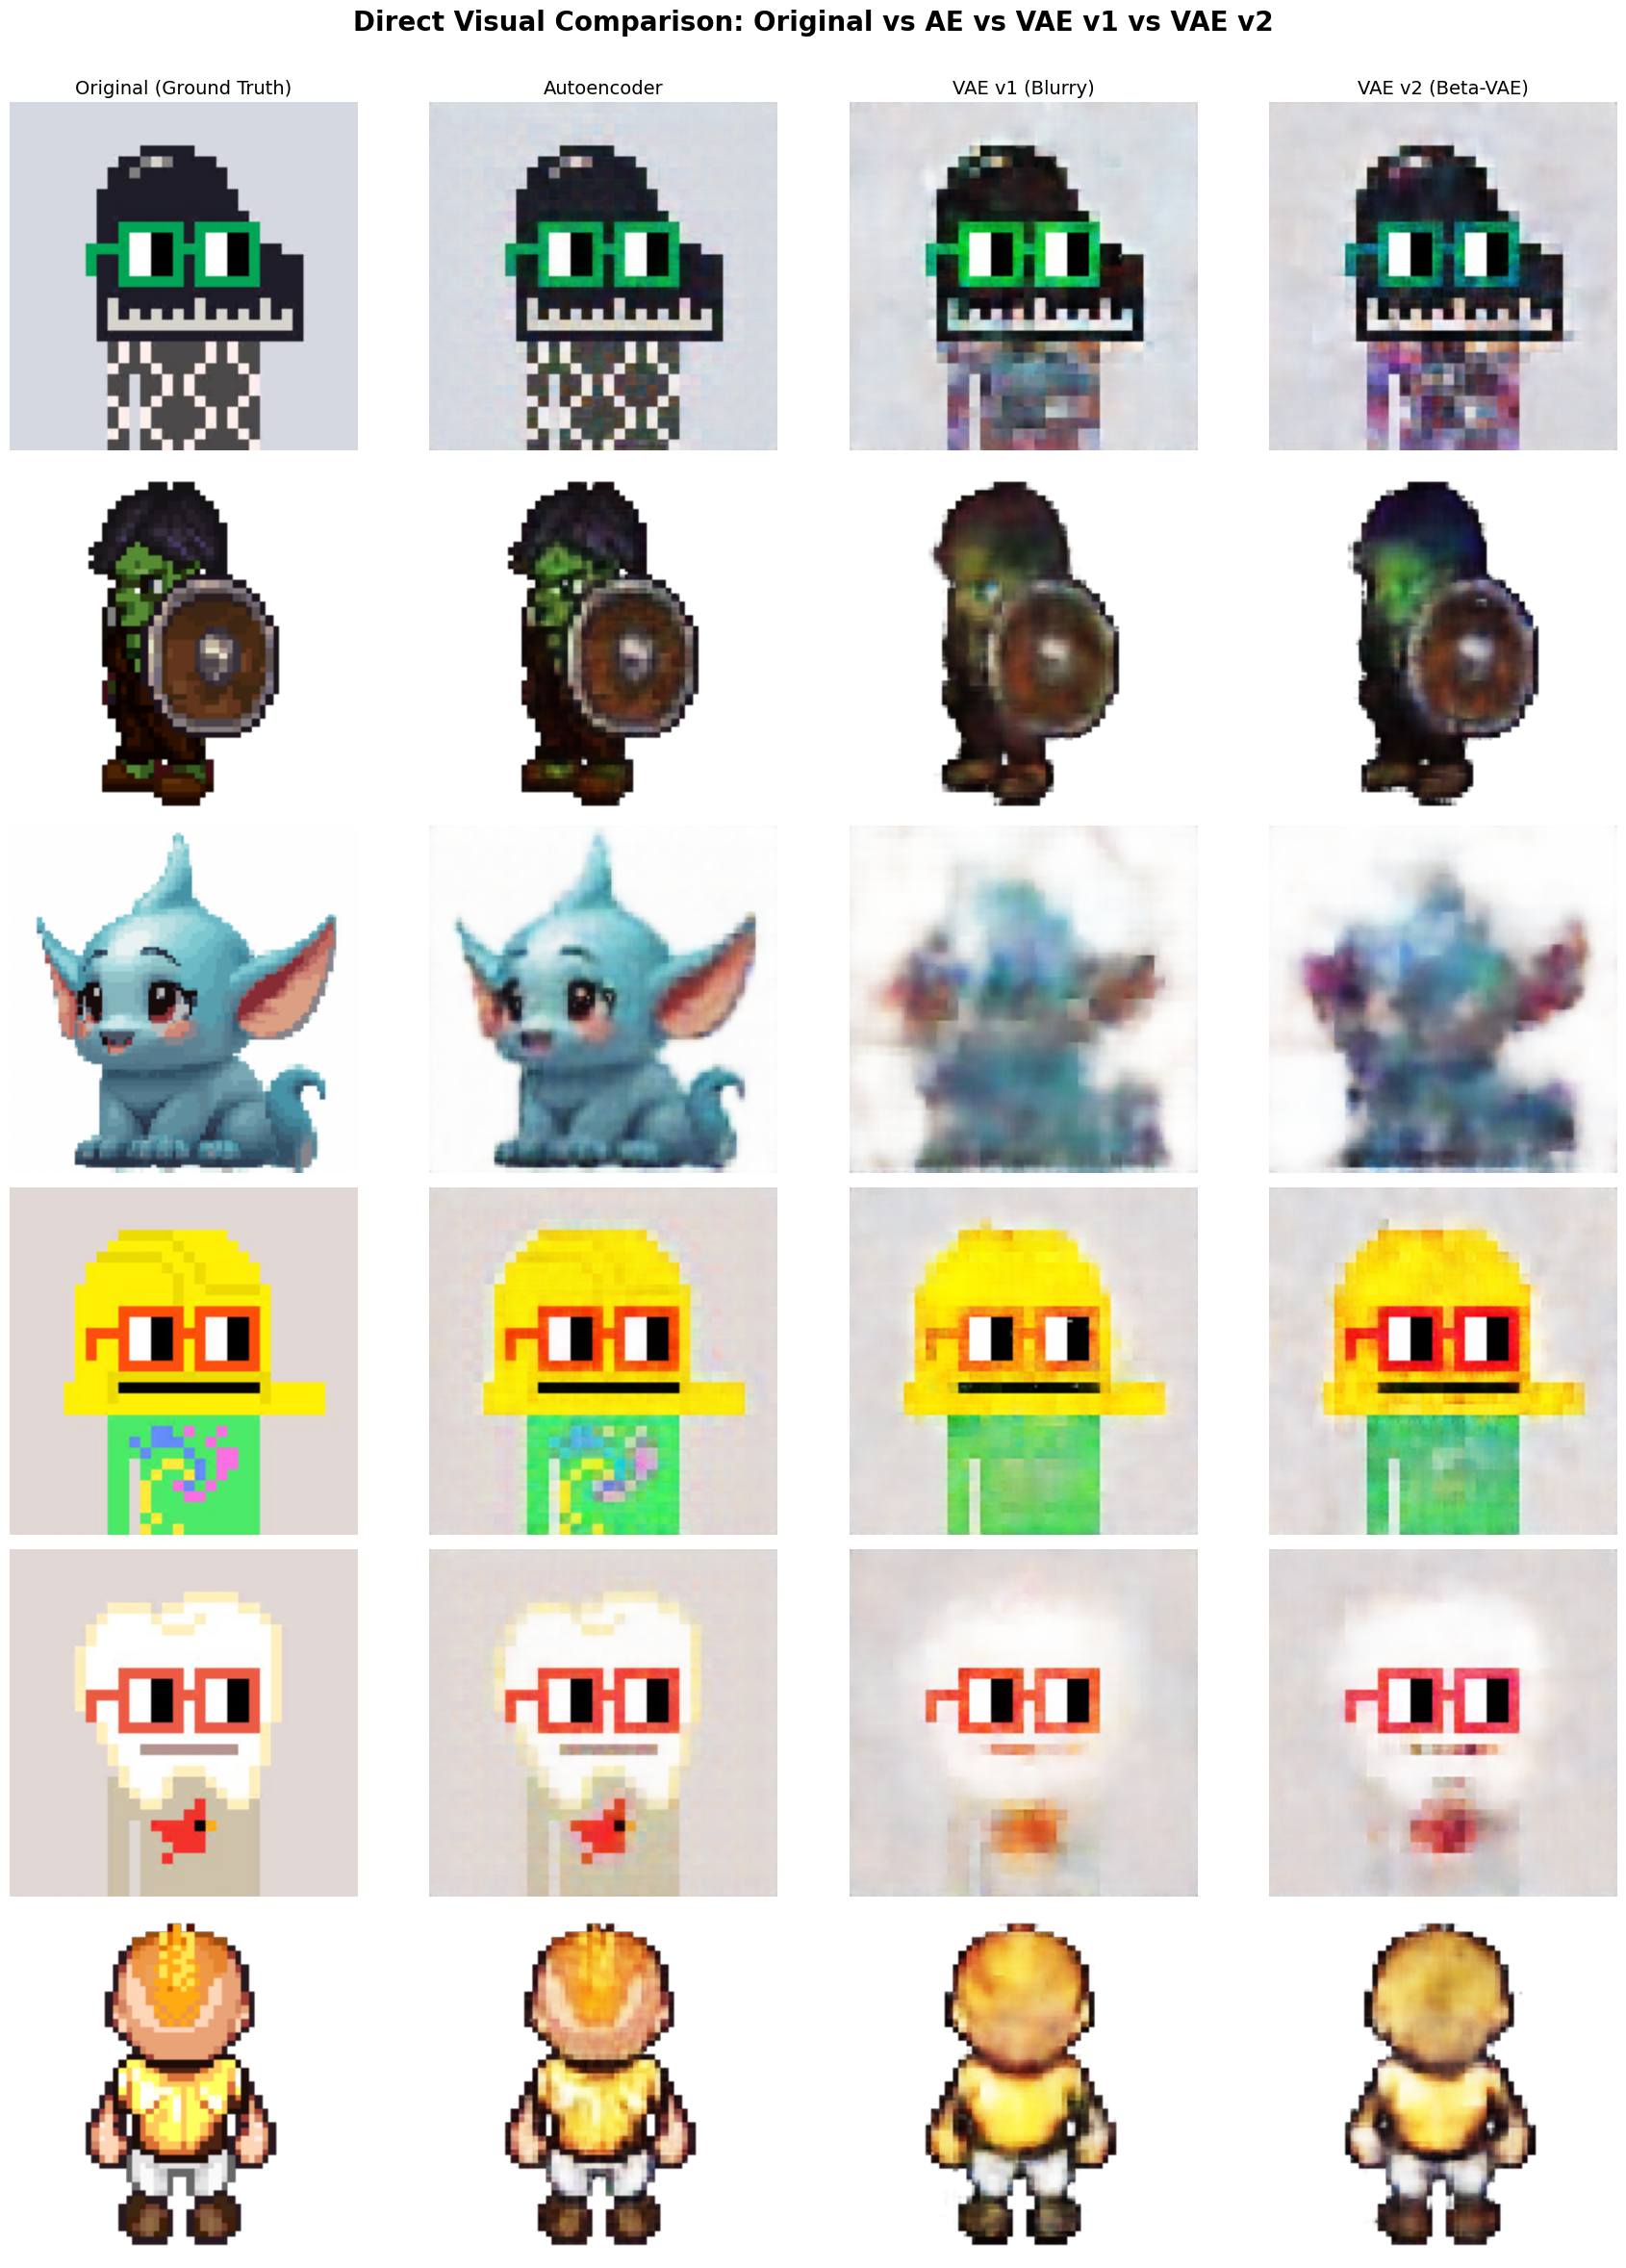

In [16]:
random_indices = random.sample(range(len(test_originals)), 6)

fig, axes = plt.subplots(6, 4, figsize=(18, 24))
for i, idx in enumerate(random_indices):
    # Original
    axes[i, 0].imshow(test_originals[idx])
    axes[i, 0].set_title("Original (Ground Truth)" if i==0 else "", fontsize=14)
    axes[i, 0].axis("off")
    
    # AE
    axes[i, 1].imshow(ae_reconstructions[idx])
    axes[i, 1].set_title("Autoencoder" if i==0 else "", fontsize=14)
    axes[i, 1].axis("off")
    
    # VAE v1
    axes[i, 2].imshow(vae_v1_reconstructions[idx])
    axes[i, 2].set_title("VAE v1 (Blurry)" if i==0 else "", fontsize=14)
    axes[i, 2].axis("off")

    # VAE v2
    axes[i, 3].imshow(vae_v2_reconstructions[idx])
    axes[i, 3].set_title("VAE v2 (Beta-VAE)" if i==0 else "", fontsize=14)
    axes[i, 3].axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.suptitle("Direct Visual Comparison: Original vs AE vs VAE v1 vs VAE v2", fontsize=20, weight='bold')
plt.show()


## 4. Comprehensive Quantitative Evaluation
Comparing all mathematical metrics to see exactly how much the Beta parameter improved the VAE's fidelity.


In [17]:
# Compute Metrics
# MSE
ae_mse = np.mean(np.square(test_originals - ae_reconstructions))
vae_v1_mse = np.mean(np.square(test_originals - vae_v1_reconstructions))
vae_v2_mse = np.mean(np.square(test_originals - vae_v2_reconstructions))

# MAE
ae_mae = np.mean(np.abs(test_originals - ae_reconstructions))
vae_v1_mae = np.mean(np.abs(test_originals - vae_v1_reconstructions))
vae_v2_mae = np.mean(np.abs(test_originals - vae_v2_reconstructions))

# PSNR
ae_psnr = np.mean(tf.image.psnr(test_originals, ae_reconstructions, max_val=1.0).numpy())
vae_v1_psnr = np.mean(tf.image.psnr(test_originals, vae_v1_reconstructions, max_val=1.0).numpy())
vae_v2_psnr = np.mean(tf.image.psnr(test_originals, vae_v2_reconstructions, max_val=1.0).numpy())

# SSIM
ae_ssim = np.mean(tf.image.ssim(test_originals, ae_reconstructions, max_val=1.0).numpy())
vae_v1_ssim = np.mean(tf.image.ssim(test_originals, vae_v1_reconstructions, max_val=1.0).numpy())
vae_v2_ssim = np.mean(tf.image.ssim(test_originals, vae_v2_reconstructions, max_val=1.0).numpy())

print("=" * 85)
print(f"{'EVALUATION METRICS (10K TEST SET)':^85}")
print("=" * 85)
print(f"{'Metric':<25} | {'Autoencoder':<15} | {'VAE v1 (Blurry)':<15} | {'VAE v2 (Beta)'}")
print("-" * 85)
print(f"{'MSE (Lower is better)':<25} | {ae_mse:<15.6f} | {vae_v1_mse:<15.6f} | {vae_v2_mse:.6f}")
print(f"{'MAE (Lower is better)':<25} | {ae_mae:<15.6f} | {vae_v1_mae:<15.6f} | {vae_v2_mae:.6f}")
print(f"{'PSNR (Higher is better)':<25} | {ae_psnr:<11.2f} dB | {vae_v1_psnr:<11.2f} dB | {vae_v2_psnr:.2f} dB")
print(f"{'SSIM (Higher is better)':<25} | {ae_ssim:<15.4f} | {vae_v1_ssim:<15.4f} | {vae_v2_ssim:.4f}")
print("=" * 85)

print(f"\nAnalysis of VAE v2 vs VAE v1:")
print(f"- MSE Improvement : {(vae_v1_mse - vae_v2_mse):.6f} lower error")
print(f"- PSNR Improvement: {(vae_v2_psnr - vae_v1_psnr):.2f} dB sharper")
print(f"- SSIM Improvement: {(vae_v2_ssim - vae_v1_ssim):.4f} better structure")


                          EVALUATION METRICS (10K TEST SET)                          
Metric                    | Autoencoder     | VAE v1 (Blurry) | VAE v2 (Beta)
-------------------------------------------------------------------------------------
MSE (Lower is better)     | 0.001666        | 0.009048        | 0.008524
MAE (Lower is better)     | 0.015185        | 0.036899        | 0.035449
PSNR (Higher is better)   | 28.52       dB | 21.24       dB | 21.62 dB
SSIM (Higher is better)   | 0.9248          | 0.7986          | 0.8032

Analysis of VAE v2 vs VAE v1:
- MSE Improvement : 0.000524 lower error
- PSNR Improvement: 0.38 dB sharper
- SSIM Improvement: 0.0046 better structure


## 5. Advanced VAE Deep Diagnostics
Per the diagnostic request, we analyze the structure of the latent space to understand the balance between Reconstruction and KL Divergence.


Running deep diagnostics on VAE v2...
LATENT POSTERIOR DISTRIBUTION CHECK
Target Distribution: Mean = 0.0, Std = 1.0 (Standard Normal)
Actual Distribution: Mean = -0.0604, Std = 1.7489


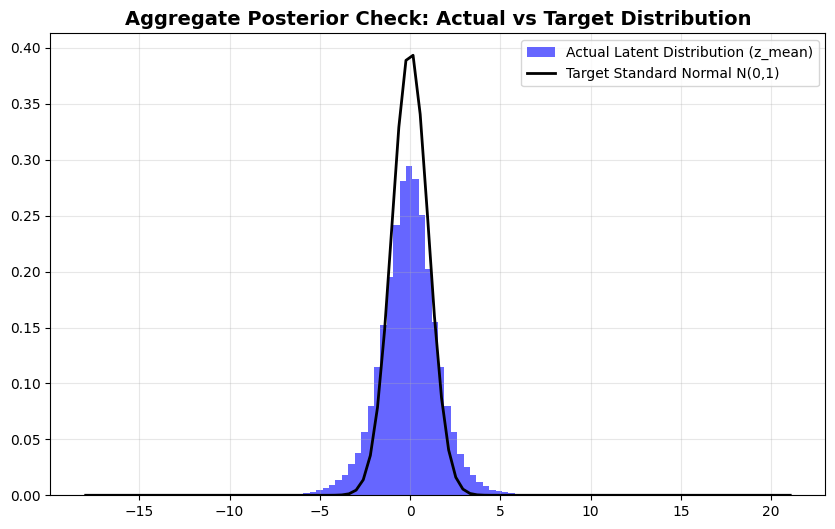

LOSS BALANCE DIAGNOSTIC
Reconstruction Loss (SSE) : 558.62
Raw KL Divergence Loss    : 1303.42
Weighted KL Loss (beta)   : 1.30 (beta = 0.001)
Ratio (Weighted KL / Recon): 0.2333%


In [18]:
import scipy.stats as stats

print("Running deep diagnostics on VAE v2...")
# 1. Encode the entire test set
z_mean, z_log_var, z = vae_v2_encoder.predict(test_originals, batch_size=32, verbose=0)

# Calculate empirical mean and std of the latent representations
empirical_mean = np.mean(z_mean)
empirical_std = np.std(z_mean)

print("=" * 60)
print("LATENT POSTERIOR DISTRIBUTION CHECK")
print("=" * 60)
print(f"Target Distribution: Mean = 0.0, Std = 1.0 (Standard Normal)")
print(f"Actual Distribution: Mean = {empirical_mean:.4f}, Std = {empirical_std:.4f}")
print("=" * 60)

# 2. Plotting the Aggregate Posterior vs Standard Normal
plt.figure(figsize=(10, 6))
# Flatten all 256 dimensions across 1000 images
flat_z = z_mean.flatten()

# Plot histogram of actual latent variables
plt.hist(flat_z, bins=100, density=True, alpha=0.6, color='b', label='Actual Latent Distribution (z_mean)')

# Plot target standard normal curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, 0, 1)
plt.plot(x, p, 'k', linewidth=2, label='Target Standard Normal N(0,1)')

plt.title("Aggregate Posterior Check: Actual vs Target Distribution", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. KL Loss Value Check
# Calculate explicit KL Divergence on the test set
kl_divergence = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
raw_kl_loss = tf.reduce_mean(tf.reduce_sum(kl_divergence, axis=1)).numpy()
beta = 0.001
weighted_kl_loss = raw_kl_loss * beta

reconstruction_loss = np.mean(np.sum(np.square(test_originals - vae_v2_reconstructions), axis=(1, 2, 3)))

print("=" * 60)
print("LOSS BALANCE DIAGNOSTIC")
print("=" * 60)
print(f"Reconstruction Loss (SSE) : {reconstruction_loss:.2f}")
print(f"Raw KL Divergence Loss    : {raw_kl_loss:.2f}")
print(f"Weighted KL Loss (beta)   : {weighted_kl_loss:.2f} (beta = {beta})")
print(f"Ratio (Weighted KL / Recon): {(weighted_kl_loss / reconstruction_loss)*100:.4f}%")
print("=" * 60)



## 6. Single Asset Variation (The 'Variant of a Goblin' Test)
Our primary goal for the VAE is to generate variations of existing assets. Instead of sampling from the global standard normal (which we proved fails right now due to prior mismatch), this test samples from the *local neighborhood* immediately surrounding a known, real sprite using its specific $\mu$ and $\sigma$.


Generating Local Neighborhood Variants...


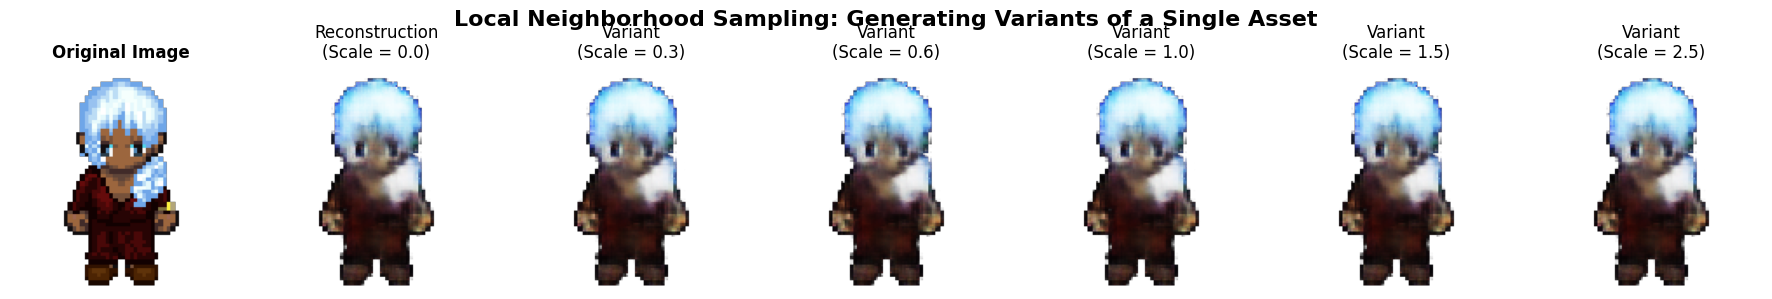

In [19]:
import random
print("Generating Local Neighborhood Variants (Fixed Direction)...")

# 1. Pick a random image from the test set
random_idx = random.randint(0, len(test_originals) - 1)
base_img = test_originals[random_idx:random_idx+1]

# 2. Get this specific image's latent statistics
z_mean, z_log_var, _ = vae_v2_encoder.predict(base_img, verbose=0)
z_sigma = tf.exp(0.5 * z_log_var)

# 3. Define the 'small_scale' multipliers to explore how far we can push before it breaks
scales = [0.0, 0.3, 0.6, 1.0, 1.5, 2.5]
num_variants = len(scales)

fig, axes = plt.subplots(1, num_variants + 1, figsize=(18, 3))

# Plot Original
axes[0].imshow(base_img[0])
axes[0].set_title("Original Image", weight='bold')
axes[0].axis("off")

# 4. Generate variants using a fixed direction of variation (epsilon)
# Pulling epsilon out of the loop allows us to scale along a single continuous latent direction
epsilon = tf.random.normal(shape=tf.shape(z_mean))

# Generate and plot variants
for i, scale in enumerate(scales):
    # z_variant = mu + scale * sigma * epsilon
    z_variant = z_mean + (scale * z_sigma * epsilon)
    
    variant_img = vae_v2_decoder.predict(z_variant, verbose=0)
    
    axes[i+1].imshow(variant_img[0])
    if scale == 0.0:
        axes[i+1].set_title(f"Reconstruction\n(Scale = 0.0)")
    else:
        axes[i+1].set_title(f"Variant\n(Scale = {scale})")
    axes[i+1].axis("off")

plt.suptitle("Local Neighborhood Sampling: Generating Variants of a Single Asset", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


### Method 2: Prior-Scaled Local Sampling (Escaping the Invariance Bubble)
To generate distinct visual variations (variants), we must perturb the latent representation beyond the encoder's high-precision reconstruction bubble (which is restricted to size `z_sigma`). Here, we scale the perturbation directly by `epsilon` (where the global prior variance is 1.0) along the **exact same direction** as the cell above to visually compare the difference.

Generating Prior-Scaled Local Variants...


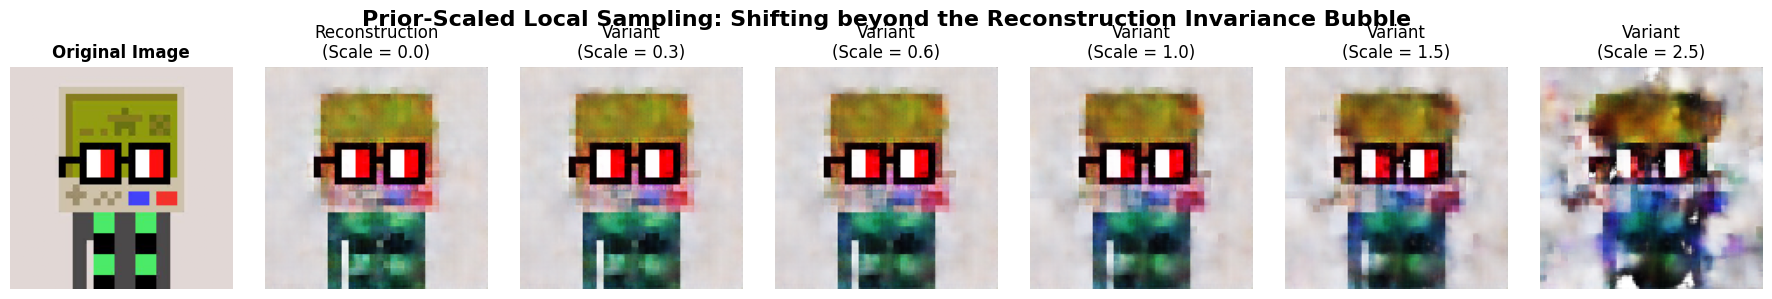

In [10]:
print("Generating Prior-Scaled Local Variants...")

# 1. Define the scales for prior-scaled sampling (matching scales above)
scales_prior = [0.0, 0.3, 0.6, 1.0, 1.5, 2.5]
num_variants_prior = len(scales_prior)

fig, axes = plt.subplots(1, num_variants_prior + 1, figsize=(18, 3))

# Plot Original
axes[0].imshow(base_img[0])
axes[0].set_title("Original Image", weight='bold')
axes[0].axis("off")

# 2. Generate and plot variants
# We reuse the exact same direction vector 'epsilon' and 'z_mean' from the cell above,
# but scale directly (without multiplying by the tiny z_sigma noise threshold).
for i, scale in enumerate(scales_prior):
    z_variant = z_mean + (scale * epsilon)
    variant_img = vae_v2_decoder.predict(z_variant, verbose=0)
    
    axes[i+1].imshow(variant_img[0])
    if scale == 0.0:
        axes[i+1].set_title(f"Reconstruction\n(Scale = 0.0)")
    else:
        axes[i+1].set_title(f"Variant\n(Scale = {scale})")
    axes[i+1].axis("off")

plt.suptitle("Prior-Scaled Local Sampling: Shifting beyond the Reconstruction Invariance Bubble", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


### Method 3: Generalization Check (12 Random Sprites)
Before scaling this flat VAE architecture to the full 280K dataset on Kaggle, we run a gate check. We select 12 random sprites from the test set and generate variants for each using the global-prior-scale fix (`scale = 1.2`) to confirm that visual variation generalizes reliably across a wide range of different assets.

Running Generalization Check on 12 Random Sprites...


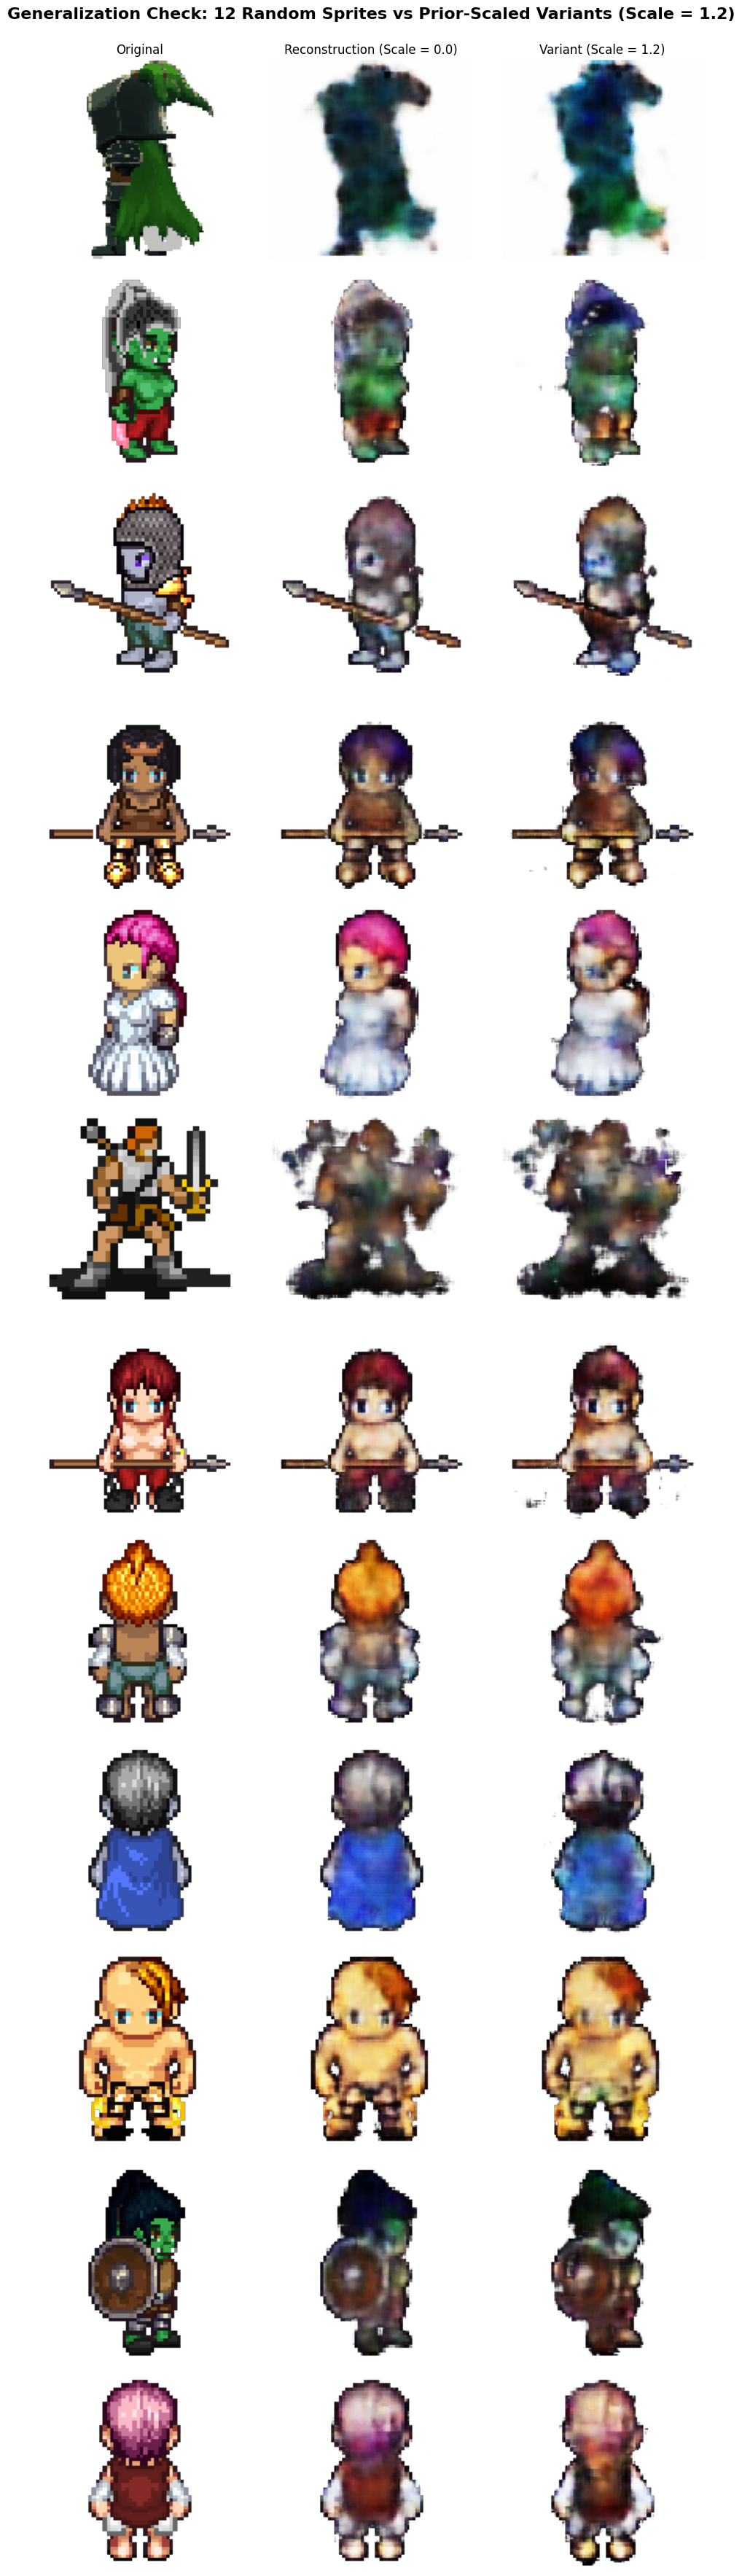

In [11]:
print("Running Generalization Check on 12 Random Sprites...")

# 1. Select 12 random sprites from the test set
random_test_indices = random.sample(range(len(test_originals)), 12)
selected_sprites = test_originals[random_test_indices]

# 2. Encode all 12 sprites to latent space
z_means, z_log_vars, _ = vae_v2_encoder.predict(selected_sprites, batch_size=12, verbose=0)

# 3. Generate variants using global prior scale (scale = 1.2 is a solid compromise for clear variation without mutation)
scale_gen = 1.2
# Generate a random direction vector for each of the 12 sprites
epsilons = tf.random.normal(shape=tf.shape(z_means))
z_variants_gen = z_means + (scale_gen * epsilons)

# 4. Decode the variants and reconstructions
decoded_variants = vae_v2_decoder.predict(z_variants_gen, batch_size=12, verbose=0)
decoded_recons = vae_v2_decoder.predict(z_means, batch_size=12, verbose=0)

# 5. Plot 12 rows: Original, Reconstruction, and Variant (Scale = 1.2)
fig, axes = plt.subplots(12, 3, figsize=(10, 36))

for i in range(12):
    # Original
    axes[i, 0].imshow(selected_sprites[i])
    axes[i, 0].set_title("Original" if i==0 else "")
    axes[i, 0].axis("off")
    
    # Reconstruction
    axes[i, 1].imshow(decoded_recons[i])
    axes[i, 1].set_title("Reconstruction (Scale = 0.0)" if i==0 else "")
    axes[i, 1].axis("off")
    
    # Variant
    axes[i, 2].imshow(decoded_variants[i])
    axes[i, 2].set_title(f"Variant (Scale = {scale_gen})" if i==0 else "")
    axes[i, 2].axis("off")

plt.suptitle(f"Generalization Check: 12 Random Sprites vs Prior-Scaled Variants (Scale = {scale_gen})", fontsize=16, weight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()


### Method 4: Quantitative Evaluation & Outlier Hypothesis Verification
To back up the visual inspect with defensible numbers for the report, we calculate the exact Reconstruction MSEs for both the Autoencoder and the VAE, compute their rank correlation to confirm the outlier hypothesis, and measure the VAE variant MSEs.

In [12]:
import scipy.stats as stats
import random

# 1. Select the same 12 random indices used in the generalization check
# (We run AE on these same sprites to compare reconstruction error rankings)
random.seed(42)
random_test_indices = random.sample(range(len(test_originals)), 12)
selected_sprites = test_originals[random_test_indices]

# 2. Run AE reconstructions
ae_recons = ae.predict(selected_sprites, verbose=0)
ae_mses = [float(np.mean(np.square(selected_sprites[i] - ae_recons[i]))) for i in range(12)]

# 3. Run VAE reconstructions & prior-scaled variants (scale = 1.2)
z_means, z_log_vars, _ = vae_v2_encoder.predict(selected_sprites, verbose=0)
scale_gen = 1.2
tf.random.set_seed(42)
epsilons = tf.random.normal(shape=tf.shape(z_means))
z_variants_gen = z_means + (scale_gen * epsilons)

decoded_recons = vae_v2_decoder.predict(z_means, verbose=0)
decoded_variants = vae_v2_decoder.predict(z_variants_gen, verbose=0)

vae_mses = [float(np.mean(np.square(selected_sprites[i] - decoded_recons[i]))) for i in range(12)]
variant_mses = [float(np.mean(np.square(decoded_recons[i] - decoded_variants[i]))) for i in range(12)]

# 4. Print results table
print("=" * 80)
print(f"{'QUANTITATIVE COMPARISON OF 12 SPRITES':^80}")
print("=" * 80)
print(f"{'Sprite Idx':<12} | {'AE Recon MSE':<18} | {'VAE Recon MSE':<18} | {'VAE Variant MSE'}")
print("-" * 80)
for i in range(12):
    print(f"{random_test_indices[i]:<12} | {ae_mses[i]:<18.6f} | {vae_mses[i]:<18.6f} | {variant_mses[i]:.6f}")
print("=" * 80)

# 5. Calculate Spearman Correlation between AE and VAE reconstruction errors
rho, p_val = stats.spearmanr(ae_mses, vae_mses)
print(f"Spearman's Rank Correlation (AE vs VAE Reconstruction MSE):")
print(f"  rho = {rho:.4f} (p-value = {p_val:.4f})")
print(f"  Interpretation: {'Strong positive correlation (Confirms outlier hypothesis)' if rho > 0.7 else 'Weak correlation (Refutes outlier hypothesis)'}")
print("-" * 80)
print(f"Average VAE Reconstruction MSE        : {np.mean(vae_mses):.6f}")
print(f"Average VAE Variant MSE (Scale = 1.2) : {np.mean(variant_mses):.6f}")
print(f"Ratio (Variant MSE / VAE Recon MSE)   : {np.mean(variant_mses)/np.mean(vae_mses):.2f}x")
print("=" * 80)


                     QUANTITATIVE COMPARISON OF 12 SPRITES                      
Sprite Idx   | AE Recon MSE       | VAE Recon MSE      | VAE Variant MSE
--------------------------------------------------------------------------------
654          | 0.002048           | 0.008128           | 0.006953
114          | 0.001171           | 0.005797           | 0.005383
25           | 0.001957           | 0.006947           | 0.004599
759          | 0.001432           | 0.007792           | 0.005139
281          | 0.002476           | 0.006237           | 0.006316
250          | 0.000835           | 0.004167           | 0.004044
228          | 0.001083           | 0.006668           | 0.006549
142          | 0.000903           | 0.005595           | 0.004771
754          | 0.002641           | 0.059419           | 0.039863
104          | 0.001681           | 0.008257           | 0.007587
692          | 0.000991           | 0.004729           | 0.004096
758          | 0.000582           | 0.0